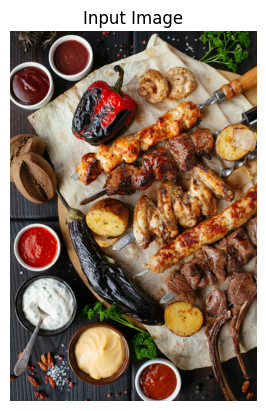

🔍 Sentiment Prediction Probabilities:
- "This food looks absolutely delicious and fresh.": 0.2396
- "The dish looks okay, nothing special.": 0.0082
- "This looks unappetizing and bad.": 0.0574
- "Yummy and mouth-watering!": 0.5744
- "It looks bland and boring.": 0.0015
- "Just an average plate of food.": 0.1188

✅ Final Sentiment: **Positive**
📝 Matched Prompt: "Yummy and mouth-watering!"


In [ ]:
# ✅ Step 1: Install required libraries
!pip install transformers torchvision pillow --quiet

# ✅ Step 2: Import libraries
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
import matplotlib.pyplot as plt

# ✅ Step 3: Load pretrained CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# ✅ Step 4: Load image from URL
# 🍝 New image of tasty food (pasta dish)
image_url = "https://images.unsplash.com/photo-1555939594-58d7cb561ad1?q=80&w=1374&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
# Download and load the image
response = requests.get(image_url, stream=True)

# ✅ Check if the request was successful
if response.status_code != 200:
    print(f"🚨 Error: Failed to retrieve image from {image_url}. Status code: {response.status_code}")
    # You might want to exit or handle this failure gracefully here
    # For example, you could use a placeholder image or skip the rest of the code
else:
    response.raw.decode_content = True
    try:
        image = Image.open(response.raw).convert("RGB")  # Convert to RGB (needed for CLIP)

        # ✅ Sentiment-related text prompts (Positive, Neutral, Negative)
        text_inputs = [
            "This food looks absolutely delicious and fresh.",   # Positive
            "The dish looks okay, nothing special.",             # Neutral
            "This looks unappetizing and bad.",                  # Negative
            "Yummy and mouth-watering!",                         # Positive
            "It looks bland and boring.",                        # Negative
            "Just an average plate of food.",                    # Neutral
        ]

        # ✅ Step 5: Display the image
        plt.imshow(image)
        plt.axis("off")
        plt.title("Input Image")
        plt.show()

        # ✅ Step 6: Process image and text together using CLIP processor
        inputs = processor(text=text_inputs, images=image, return_tensors="pt", padding=True).to(device)

        # ✅ Step 7: Pass inputs through the CLIP model
        outputs = model(**inputs)
        logits_per_image = outputs.logits_per_image  # similarity scores [1, N]
        probs = logits_per_image.softmax(dim=1)      # normalize to probabilities

        # ✅ Step 8: Display sentiment probabilities
        print("🔍 Sentiment Prediction Probabilities:")
        for i, text in enumerate(text_inputs):
            print(f"- \"{text}\": {probs[0][i].item():.4f}")

        # ✅ Step 9: Get most likely sentiment and print result
        predicted_index = torch.argmax(probs, dim=1).item()
        predicted_text = text_inputs[predicted_index]

        # Categorize as Positive / Neutral / Negative based on prompt used
        if "delicious" in predicted_text or "Yummy" in predicted_text:
            sentiment_category = "Positive"
        elif "okay" in predicted_text or "average" in predicted_text:
            sentiment_category = "Neutral"
        else:
            sentiment_category = "Negative"

        print(f"\n✅ Final Sentiment: **{sentiment_category}**")
        print(f"📝 Matched Prompt: \"{predicted_text}\"")

    except UnidentifiedImageError:
        print("🚨 Error: Could not identify the image file from the downloaded data.")